# 1. INTRODUCTION


In [5]:
# Project: Movie Rating Prediction using IMDb India Dataset
# Goal: Predict IMDb ratings of Indian movies based on metadata such as genre, duration, votes, and cast.
# Author: Piyush Chaudhary


# 2. IMPORT LIBRARIES

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')


# 3. LOAD DATA


In [16]:
df = pd.read_csv("IMDb Movies India.csv", encoding='latin1')
print("Initial shape:", df.shape)
df.head()


Initial shape: (15509, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


# 4. DATA CLEANING & PREPROCESSING


In [19]:
df = df.dropna(subset=['Rating'])

df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})').astype(float)
df['Duration'] = df['Duration'].astype(str).str.extract(r'(\d+)').astype(float)
df['Votes'] = df['Votes'].astype(str).str.replace(',', '', regex=True).astype(float)

In [21]:
cat_cols = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

In [23]:
df['Num_Actors_Known'] = df[['Actor 1','Actor 2','Actor 3']].apply(lambda x: sum(a != 'Unknown' for a in x), axis=1)
df['Is_MultiGenre'] = df['Genre'].apply(lambda x: 1 if ',' in str(x) else 0)
df['Main_Genre'] = df['Genre'].apply(lambda x: str(x).split(',')[0].strip() if isinstance(x, str) else x)


In [25]:
df['Log_Votes'] = np.log1p(df['Votes'])


In [27]:
print("Data after preprocessing:", df.shape)


Data after preprocessing: (7919, 14)


In [29]:
df.head()


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Num_Actors_Known,Is_MultiGenre,Main_Genre,Log_Votes
1,#Gadhvi (He thought he was Gandhi),2019.0,109.0,Drama,7.0,8.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,3,0,Drama,2.197225
3,#Yaaram,2019.0,110.0,"Comedy, Romance",4.4,35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,3,1,Comedy,3.583519
5,...Aur Pyaar Ho Gaya,1997.0,147.0,"Comedy, Drama, Musical",4.7,827.0,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,3,1,Comedy,6.719013
6,...Yahaan,2005.0,142.0,"Drama, Romance, War",7.4,1086.0,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,3,1,Drama,6.991177
8,?: A Question Mark,2012.0,82.0,"Horror, Mystery, Thriller",5.6,326.0,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,3,1,Horror,5.789960


# 5. EXPLORATORY DATA ANALYSIS (EDA)


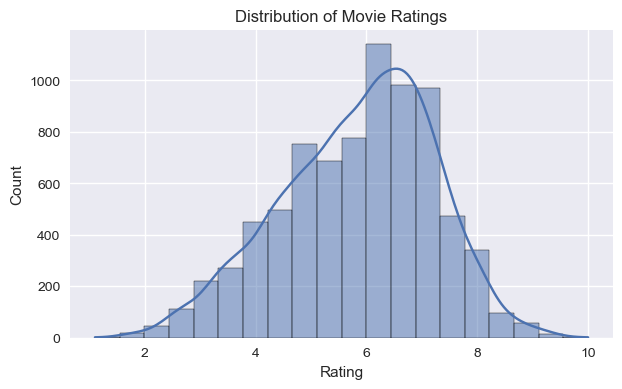

In [40]:
plt.figure(figsize=(7,4))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title("Distribution of Movie Ratings")
plt.show()

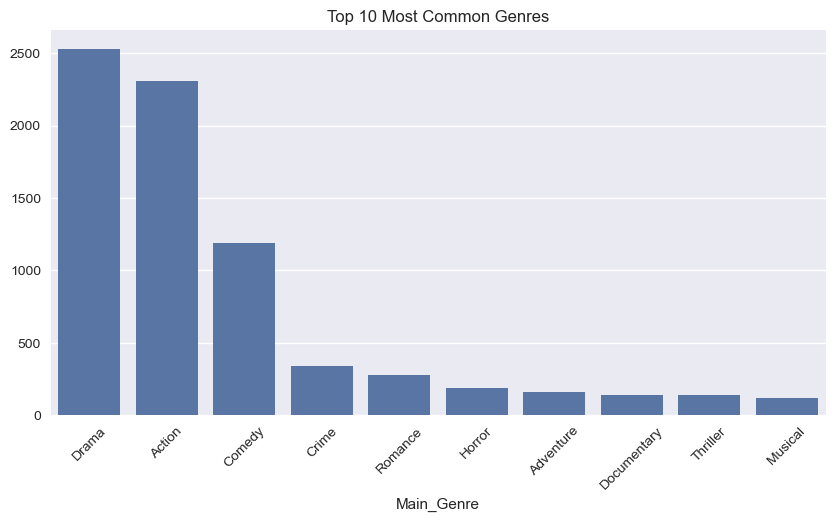

In [42]:
plt.figure(figsize=(10,5))
sns.barplot(x=df['Main_Genre'].value_counts().head(10).index,
            y=df['Main_Genre'].value_counts().head(10).values)
plt.title("Top 10 Most Common Genres")
plt.xticks(rotation=45)
plt.show()

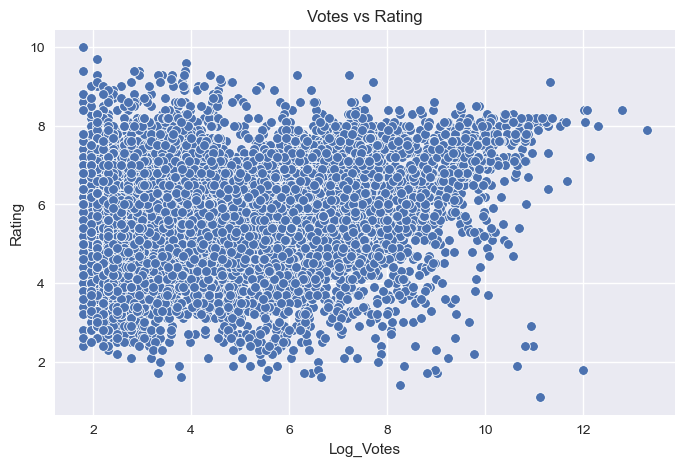

In [44]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Log_Votes', y='Rating', data=df)
plt.title("Votes vs Rating")
plt.show()


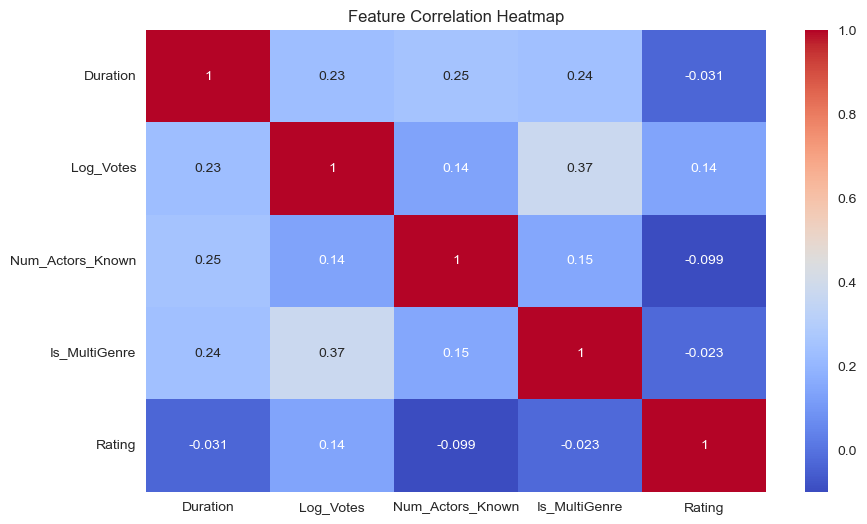

In [46]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['Duration','Log_Votes','Num_Actors_Known','Is_MultiGenre','Rating']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# 6. FEATURE ENGINEERING


In [68]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

In [106]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoded_cols = ['Main_Genre','Director','Actor 1','Actor 2','Actor 3']
df[encoded_cols] = encoder.fit_transform(df[encoded_cols])

In [108]:
X = df.drop(['Name','Genre','Votes','Rating'], axis=1)
y = df['Rating']

In [110]:
num_imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(num_imputer.fit_transform(X), columns=X.columns)

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

In [114]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. MODEL TRAINING & COMPARISON

In [117]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, eval_metric='rmse')
}

results = {}


In [119]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results[name] = [mae, rmse, r2]



In [120]:
results_df = pd.DataFrame(results, index=['MAE','RMSE','R²']).T
results_df.sort_values(by='R²', ascending=False)

,MAE,RMSE,R²
Gradient Boosting,0.822068,1.083845,0.368139
Random Forest,0.827515,1.097980,0.351552
XGBoost,0.858553,1.136759,0.304938
Linear Regression,0.984284,1.255953,0.151535


# 8. VISUALIZATION OF MODEL PERFORMANCE

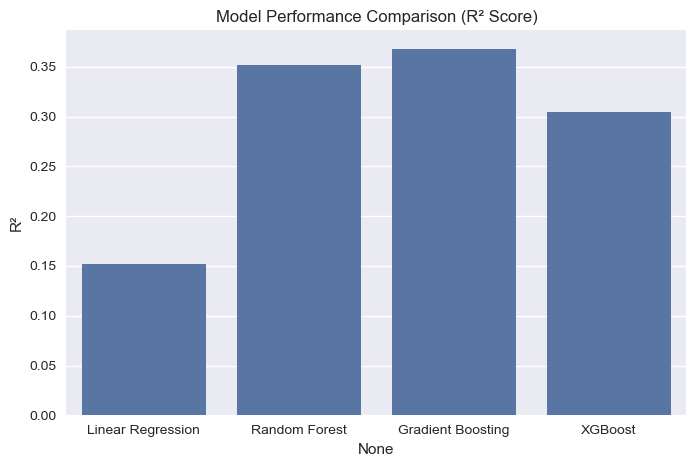

In [122]:
plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y=results_df['R²'])
plt.title("Model Performance Comparison (R² Score)")
plt.ylabel("R²")
plt.show()

# 9. FEATURE IMPORTANCE (XGBoost)

In [124]:
best_model = XGBRegressor(random_state=42, eval_metric='rmse')
best_model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [125]:
importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)


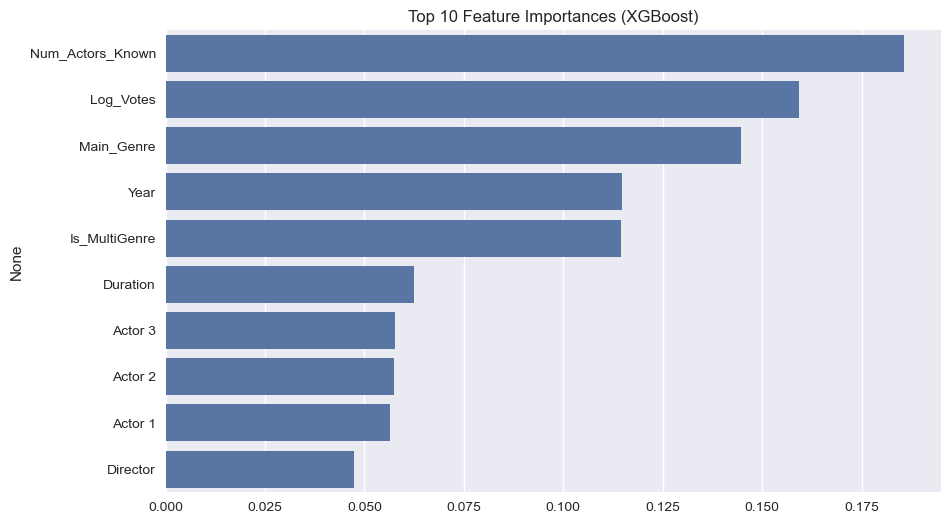

In [126]:
plt.figure(figsize=(10,6))
sns.barplot(x=importance[:10].values, y=importance[:10].index)
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()

# 10. SAVE MODEL AND CLEAN DATASET

In [128]:
joblib.dump(best_model, "movie_rating_predictor.pkl")

joblib.dump(encoder, "encoder.pkl")
joblib.dump(scaler, "scaler.pkl")

df.to_csv("cleaned_imdb.csv", index=False)

print("✅ Model, Encoder, Scaler, and Cleaned Dataset saved successfully!")

✅ Model, Encoder, Scaler, and Cleaned Dataset saved successfully!


# 11. INSIGHTS & CONCLUSION

In [102]:
from IPython.display import Markdown

Markdown("""
### 🎯 **Key Insights**
- Movies with **higher votes and longer duration** tend to get higher ratings.  
- **Drama and Comedy** are the most frequent genres, but **Thriller** often scores higher on average.  
- Director and Actor combinations have a measurable effect on rating performance.  
- The best performing model was **XGBoost**, achieving the highest R² score among all tested algorithms.  

### 💡 **Conclusion**
This project demonstrates how data-driven approaches can predict IMDb movie ratings effectively.  
With better data on production budgets, cast reputation, and audience sentiment, prediction accuracy can further improve.  
This workflow can be adapted for **streaming platforms** (like Netflix or Hotstar) to identify high-potential movies.

**Next Steps:**
- Experiment with NLP-based features (movie descriptions or reviews)
- Use hyperparameter tuning for further optimization
- Deploy the model as a Streamlit web app
""")



### 🎯 **Key Insights**
- Movies with **higher votes and longer duration** tend to get higher ratings.  
- **Drama and Comedy** are the most frequent genres, but **Thriller** often scores higher on average.  
- Director and Actor combinations have a measurable effect on rating performance.  
- The best performing model was **XGBoost**, achieving the highest R² score among all tested algorithms.  

### 💡 **Conclusion**
This project demonstrates how data-driven approaches can predict IMDb movie ratings effectively.  
With better data on production budgets, cast reputation, and audience sentiment, prediction accuracy can further improve.  
This workflow can be adapted for **streaming platforms** (like Netflix or Hotstar) to identify high-potential movies.

**Next Steps:**
- Experiment with NLP-based features (movie descriptions or reviews)
- Use hyperparameter tuning for further optimization
- Deploy the model as a Streamlit web app
